# The Ocean's Longest Diving Animals

How long can air-breathing animals hold their breath while diving? Which animals can stay submerged for the longest time?

The file `longest-diving-animals.csv` contains the recorded durations, in minutes, of the longest dives ever recorded in the scientific literature for different species of marine mammals. 

In [51]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'longest-diving-animals.csv'.

# from google.colab import files
# uploaded = files.upload()

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('longest-diving-animals.csv')
df.head()

,animal,category,duration
0,Emperor Penguin,penguins,32.2
1,King Penguin,penguins,9.2
2,Rockhopper Penguin,penguins,3.2
3,Macaroni Penguin,penguins,6.3
4,Royal Penguin,penguins,7.5


### Project Ideas

- Create horizontal bar plots to show the longest diving animals, either for each category or within a category.

- Follow the Pro Tips.

- Convert dive durations from minutes to hours for easier understanding - 2.5 hours is clearer than 150 minutes.

- Add a reference bar to help readers build intuition about the durations. 

Side Note: The longest time a person has held their breath underwater is 24 minutes 37 seconds. This was done at the surface of a pool, not while freediving, so it might not directly comparable.


In [53]:
df['duration'] = df['duration'] / 60
category = df.groupby(by='category').mean(numeric_only=True).reset_index().sort_values(by='duration', ascending=True)
category

,category,duration
2,other seabirds,0.029500
3,penguins,0.109643
4,sea lions,0.186000
1,other marine mammals,0.283333
0,baleen whales,0.324762
5,seals,0.484653
6,toothed whales,0.803452
8,walruses,0.816667
7,turtles,1.141667


In [54]:
def clean_bar_axes():
	ax = plt.gca() # get current axis
	ax.spines[['top','bottom','left','right']].set_visible(False)
	ax.grid(axis='x', color='black', alpha=0.5)
	ax.tick_params(axis='both', length=0)

In [55]:
category['color'] = 'C0'
category.loc['ref_0'] = ['longest diving person', (24/60 + 37/60/60), 'C3']
category = category.sort_values('duration')
category

,category,duration,color
2,other seabirds,0.029500,C0
3,penguins,0.109643,C0
4,sea lions,0.186000,C0
1,other marine mammals,0.283333,C0
0,baleen whales,0.324762,C0
ref_0,longest diving person,0.410278,C3
5,seals,0.484653,C0
6,toothed whales,0.803452,C0
8,walruses,0.816667,C0
7,turtles,1.141667,C0


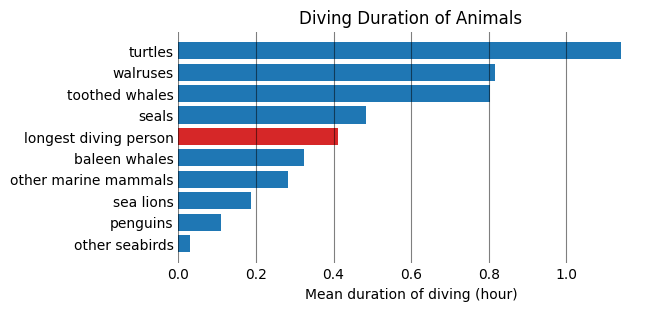

In [57]:
plt.figure(figsize=(6, 3))
plt.barh(category['category'], category['duration'], color=category['color'])
plt.xlabel('Mean duration of diving (hour)')
plt.title('Diving Duration of Animals')
clean_bar_axes()
plt.show()